In [1]:
#Importting the libaries for modelling
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import normalize
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [63]:
url =  'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
row_data = pd.read_csv(url)
row_data = row_data.drop(['payment_type','VendorID','store_and_fwd_flag','improvement_surcharge','passenger_count','DOLocationID','PULocationID'],axis = 1)
row_data

,trip_distance,RatecodeID,fare_amount,mta_tax,tolls_amount,tip_amount
0,17.63,2,70.0,0.5,6.94,16.54
1,19.52,2,70.0,0.5,6.94,16.19
2,17.81,2,70.0,0.5,6.94,12.00
3,19.30,2,70.0,0.5,0.00,5.00
4,18.75,2,70.0,0.5,6.94,10.00
...,...,...,...,...,...,...
41197,16.94,2,70.0,0.5,6.94,5.00
41198,19.83,2,70.0,0.5,6.94,8.00
41199,17.31,2,70.0,0.5,6.94,8.00
41200,17.28,2,70.0,0.5,6.94,16.19


In [64]:
correlation_value = row_data.corr()['tip_amount'].drop('tip_amount')

In [65]:
correlation_value

trip_distance    0.101819
RatecodeID       0.094075
fare_amount      0.200638
mta_tax         -0.054488
tolls_amount     0.116172
Name: tip_amount, dtype: float64

In [66]:
row_data.isnull().sum()

trip_distance    0
RatecodeID       0
fare_amount      0
mta_tax          0
tolls_amount     0
tip_amount       0
dtype: int64

In [67]:
row_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trip_distance  41202 non-null  float64
 1   RatecodeID     41202 non-null  int64  
 2   fare_amount    41202 non-null  float64
 3   mta_tax        41202 non-null  float64
 4   tolls_amount   41202 non-null  float64
 5   tip_amount     41202 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 1.9 MB


In [68]:
row_data.describe()

,trip_distance,RatecodeID,fare_amount,mta_tax,tolls_amount,tip_amount
count,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,18.384928,2.025411,69.986150,0.491020,5.608198,14.107666
std,2.856605,0.461587,6.184851,0.066404,2.979348,5.030619
min,0.000000,1.000000,3.700000,0.000000,0.000000,0.010000
25%,17.370000,2.000000,70.000000,0.500000,6.940000,10.000000
50%,18.180000,2.000000,70.000000,0.500000,6.940000,16.190000
75%,19.380000,2.000000,70.000000,0.500000,6.940000,16.190000
max,189.910000,5.000000,199.700000,0.500000,57.000000,98.000000


<Axes: >

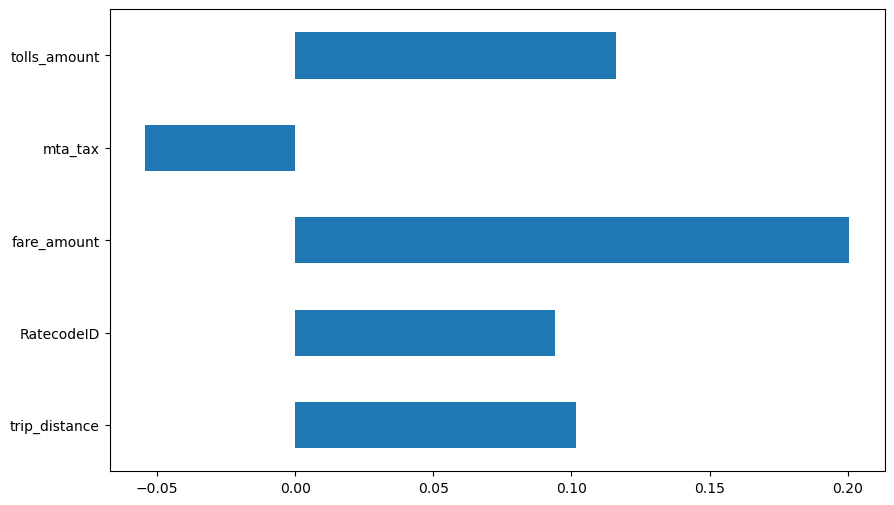

In [69]:
correlation_values = row_data.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10,6))

In [70]:
X = row_data.drop(['tip_amount'], axis = 1)
y = row_data[['tip_amount']].values.astype('float32')

In [71]:
#Normalizing the X values 
X = normalize(X, axis=1, norm='l1', copy=False)

In [72]:
#Splitting the dataset into training and testing set 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [98]:
#Builting the model
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',max_depth = 4,random_state = 45)
dt_reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,45
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [99]:
y_pred = dt_reg.predict(X_test)

In [100]:
#Evaluating the model 
mse_score = mean_squared_error(y_test,y_pred)
print(f"The MSE score is {mse_score}")

The MSE score is 24.21860767457036


In [101]:
print(f"The R2 score of the model is {np.round(100*r2_score(y_test, y_pred), 2)}%")

The R2 score of the model is 4.12%


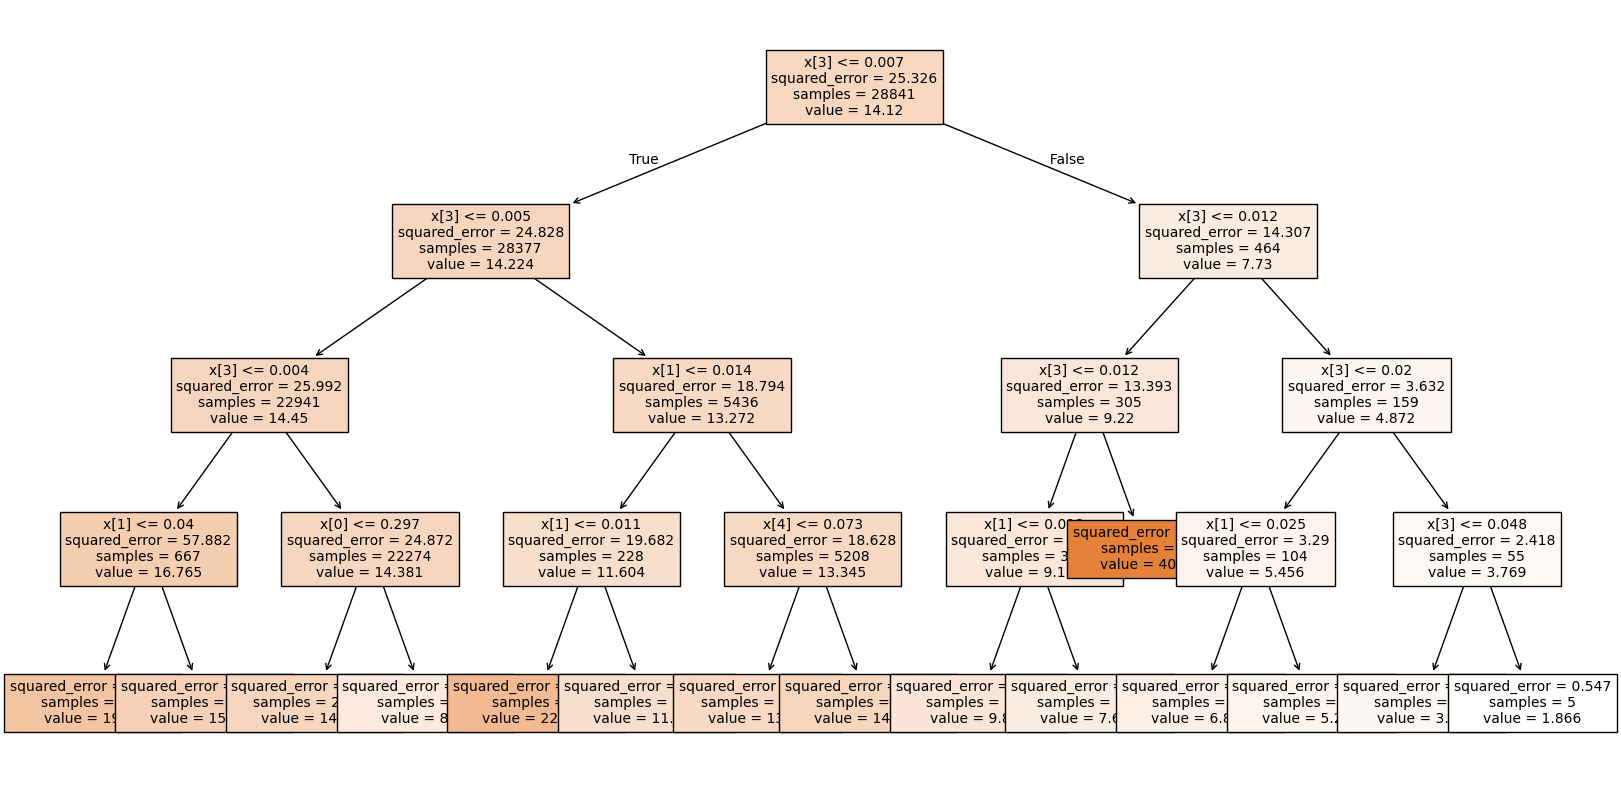

In [102]:
plt.figure(figsize=(20,10))   # make canvas big
plot_tree(dt_reg,filled=True,fontsize=10)
plt.show()